# PROJECT: AQuaMUSE — Query-Based Multi-Document News Summarization

**Pipeline:** Dataset Prep → EDA → Preprocessing → Text Representation → Keyword Extraction → Model Training → Evaluasi

**Desain Eksperimen (8 Total):**  
1 model (BART-large-cnn) × 4 keyword types (no_query, baseline, RAKE, KBmini) × 2 hyperparameter config (cfg1, cfg2)

> YAKE & KeyBERT-Dist: diekstrak untuk EDA/analisis saja, **tidak** dilatih.


## Latar Belakang Penelitian (Research Background)

Peringkasan teks abstraktif (*abstractive text summarization*) bertujuan untuk menghasilkan ringkasan yang ringkas namun tetap mempertahankan informasi semantik penting dari teks sumber. Arsitektur berbasis transformer terkini seperti **BART** (*Bidirectional and Auto-Regressive Transformer*) telah menunjukkan performa yang kuat dalam tugas peringkasan berkat struktur encoder-decoder dan kemampuan pemahaman bahasa yang telah di-pretrain.

Beberapa studi terbaru menunjukkan bahwa penggabungan *query* atau panduan kontekstual dapat meningkatkan kualitas peringkasan dengan membantu model berfokus pada informasi yang relevan. Penelitian **Query-Based Dialogue Summarization Using BART** mendemonstrasikan bahwa input yang dipandu query dapat meningkatkan relevansi dan fokus ringkasan yang dihasilkan.

Secara serupa, kerangka kerja **AQuaMUSE** memperkenalkan peringkasan multi-dokumen berbasis query (*query-based multi-document summarization / qMDS*), menunjukkan bahwa query kontekstual membantu sistem peringkasan menghasilkan ringkasan yang lebih terfokus dan relevan secara semantik.

Terinspirasi dari studi-studi tersebut, penelitian ini menginvestigasi apakah metode ekstraksi kata kunci seperti **RAKE** dan **KeyBERT MiniLM** dapat berfungsi sebagai panduan kontekstual untuk peringkasan berita abstraktif menggunakan BART.


## Tujuan Penelitian (Research Objective)

Penelitian ini bertujuan untuk:
- **Menganalisis pengaruh** peringkasan yang dipandu kata kunci (*keyword-guided summarization*) terhadap performa peringkasan abstraktif.
- **Membandingkan performa** peringkasan antara:
  - **Baseline full-context**: peringkasan dengan query + dokumen lengkap.
  - **No-query**: peringkasan tanpa query (hanya dokumen).
  - **RAKE-based keyword**: peringkasan dengan query + kata kunci dari RAKE.
  - **KeyBERT MiniLM-based keyword**: peringkasan dengan query + kata kunci semantik dari KeyBERT.
- **Mengevaluasi** ringkasan yang dihasilkan menggunakan metrik **ROUGE** (1, 2, L), **METEOR**, dan **BERTScore**.


## Celah Penelitian (Research Gap)

Studi-studi sebelumnya terutama berfokus pada peringkasan berbasis query untuk sistem dialog atau sistem pencarian multi-dokumen. Namun, **masih terbatas penelitian yang menginvestigasi dampak metode ekstraksi kata kunci ringan** (*lightweight keyword extraction*) seperti RAKE dan KeyBERT MiniLM sebagai panduan kontekstual untuk peringkasan berita abstraktif menggunakan BART.

Penelitian ini mengisi celah tersebut dengan melakukan **ablation study** yang sistematis, membandingkan 4 konfigurasi input (no-query, baseline, RAKE, KeyBERT-Mini) pada 2 set hyperparameter, sehingga menghasilkan **8 eksperimen** yang memungkinkan analisis mendalam tentang kontribusi masing-masing komponen.


## Motivasi Penggunaan Keyword Extraction

Ekstraksi kata kunci digunakan untuk mengidentifikasi informasi yang paling relevan dari dokumen input yang panjang. Dengan menyediakan kata kunci penting sebagai panduan kontekstual, model peringkasan diharapkan dapat **berfokus lebih efektif pada informasi yang menonjol** (*salient information*) sekaligus mengurangi derau konteks yang tidak relevan.

Dalam penelitian ini, dua pendekatan ekstraksi kata kunci dieksplorasi:
- **RAKE** (*Rapid Automatic Keyword Extraction*): metode statistik berbasis co-occurrence yang cepat dan tidak memerlukan model pretrained.
- **KeyBERT MiniLM** (*KBmini*): metode berbasis embedding semantik yang memanfaatkan model transformer ringan (`paraphrase-MiniLM-L6-v2`) untuk mengidentifikasi kata kunci yang paling mirip secara makna dengan dokumen.

Kedua metode ini dibandingkan terhadap konfigurasi **baseline** (hanya query tanpa keyword) dan **no-query** (tanpa query maupun keyword) untuk mengukur kontribusi nyata dari keyword extraction terhadap kualitas peringkasan.


## TAHAP 2: SETUP ENVIRONMENT & INSTALASI

In [1]:
# Uncomment untuk instalasi (Colab/Kaggle)
!pip install datasets transformers torch torchvision torchaudio sentencepiece accelerate
!pip install rake-nltk yake keybert sentence-transformers rouge-score bert-score
!pip install scikit-learn gensim requests beautifulsoup4 trafilatura lxml nltk
!pip install pandas numpy tqdm matplotlib seaborn wordcloud pyLDAvis umap-learn jupyter ipywidgets


In [2]:
import nltk
# Uncomment jika pertama kali:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Stevina\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Stevina\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Stevina\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Stevina\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Stevina\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Stevina\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-

True

In [3]:
# Standard
import os, re, json, time, hashlib, warnings
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Dataset
from datasets import load_dataset

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize

# Scraping
import requests
import trafilatura
from bs4 import BeautifulSoup

# Text Representation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

# Keyword Extraction
from rake_nltk import Rake
import yake
from keybert import KeyBERT

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud

# Deep Learning
import torch
from transformers import (
    BartTokenizer, BartForConditionalGeneration,
    Seq2SeqTrainer, Seq2SeqTrainingArguments
)
from torch.utils.data import Dataset

# Evaluasi
from rouge_score import rouge_scorer as rouge_lib
from bert_score import score as compute_bert_score

print("Semua library berhasil di-import.")
print(f"GPU tersedia: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Semua library berhasil di-import.
GPU tersedia: False


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()

USE_FP16             = torch.cuda.is_available()
USE_GRAD_CHECKPOINT  = True


Device: cpu


## TAHAP 3: LOAD DATASET & WEB SCRAPING — STRUCTURED PIPELINE

In [5]:
# ============================================================
# 3.1 CONFIGURATION & HELPERS
# ============================================================
import os, json, time, hashlib, ast
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset
import requests
import trafilatura
from bs4 import BeautifulSoup

CACHE_FILE    = 'scraping_cache.json'
HEADERS       = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Academic Research Bot'}
TIMEOUT       = 10
DELAY         = 0.1
MAX_URLS      = 3
MIN_WORDS     = 50
MAX_WORDS     = 5000
RANDOM_SEED   = 42
TRAIN_SAMPLE  = 0.50

def load_scraping_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {}

def save_scraping_cache(cache):
    with open(CACHE_FILE, 'w', encoding='utf-8') as f:
        json.dump(cache, f, ensure_ascii=False)

def scrape_single_url(url):
    if not isinstance(url, str) or not url.startswith("http"):
        return ""
    try:
        downloaded = trafilatura.fetch_url(url)
        if downloaded:
            text = trafilatura.extract(downloaded, include_comments=False, include_tables=False)
            if text and len(text.split()) > 20: return text.strip()
    except: pass
    try:
        r = requests.get(url, timeout=TIMEOUT, headers=HEADERS)
        if r.status_code == 200:
            soup = BeautifulSoup(r.text, 'html.parser')
            for tag in soup(['script', 'style', 'nav', 'footer', 'header', 'aside', 'ad']):
                tag.decompose()
            text = ' '.join(soup.get_text().split())
            if len(text.split()) > 20: return text[:8000]
    except: pass
    return ""

def build_multi_doc(row, cache):
    urls = row['input_urls']
    if isinstance(urls, str):
        try: urls = ast.literal_eval(urls)
        except: urls = []
    urls = urls[:MAX_URLS]
    if not urls: return row['query']
    url_key = hashlib.md5(str(sorted(urls)).encode()).hexdigest()
    if url_key in cache: return cache[url_key]
    scraped_texts = []
    for url in urls:
        text = scrape_single_url(url)
        if text: scraped_texts.append(text)
        time.sleep(DELAY)
    final_doc = " [SEP_DOC] ".join(scraped_texts)
    if len(final_doc.split()) < 20: final_doc = row['query']
    cache[url_key] = final_doc
    return final_doc

In [6]:
# ============================================================
# 3.2 DATA LOADING & SCRAPING EXECUTION
# ============================================================
def process_split(df, split_name, cache):
    print(f"\n>>> Processing Split: {split_name} (Total: {len(df)})")
    documents = []
    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc=f"Scraping {split_name}")):
        doc = build_multi_doc(row, cache)
        documents.append(doc)
        if (i + 1) % 50 == 0: save_scraping_cache(cache)
    df['document'] = documents
    save_scraping_cache(cache)
    return df

if os.path.exists('df_train_scraped.csv'):
    print("Loading existing scraped data...")
    df_train_clean = pd.read_csv('df_train_scraped.csv')
    df_val_clean   = pd.read_csv('df_val_scraped.csv')
    df_test_clean  = pd.read_csv('df_test_scraped.csv')
    for df in [df_train_clean, df_val_clean, df_test_clean]:
        df['input_urls'] = df['input_urls'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
else:
    print("Loading dataset from Hugging Face...")
    dataset = load_dataset("google-research-datasets/aquamuse", "abstractive")
    df_train_clean = pd.DataFrame(dataset["train"]).sample(frac=TRAIN_SAMPLE, random_state=RANDOM_SEED).reset_index(drop=True)
    df_val_clean   = pd.DataFrame(dataset["validation"])
    df_test_clean  = pd.DataFrame(dataset["test"])
    
    cache = load_scraping_cache()
    df_train_clean = process_split(df_train_clean, "Train", cache)
    df_val_clean   = process_split(df_val_clean,   "Validation", cache)
    df_test_clean  = process_split(df_test_clean,  "Test", cache)
    
    df_train_clean.to_csv('df_train_scraped.csv', index=False)
    df_val_clean.to_csv('df_val_scraped.csv', index=False)
    df_test_clean.to_csv('df_test_scraped.csv', index=False)
    print("\nRaw scraped data saved to df_XXX_scraped.csv")

Loading existing scraped data...


In [7]:
# ============================================================
# 3.3 UNIFIED CLEANING & FILTERING
# ============================================================
def clean_dataset(df, split_name):
    print(f"\nCleaning {split_name} Split:")
    initial_len = len(df)
    
    # 0. Fill NA & Basic Prep
    for col in ['document', 'query', 'target']:
        df[col] = df[col].fillna('').astype(str).str.strip()
    
    # 1. Filter by Word Count
    df['doc_len'] = df['document'].apply(lambda x: len(x.split()))
    df = df[(df['doc_len'] >= MIN_WORDS) & (df['doc_len'] <= MAX_WORDS)]
    
    # 2. Remove 'Query-only' results (fallback failures)
    df = df[df['document'].str.lower() != df['query'].str.lower()]
    
    # 3. Remove Noise Content
    bad_keywords = ['error', '404', 'not found', 'page not found', 'access denied', 'forbidden', 'login', 'sign up']
    def contains_noise(text):
        text_l = text.lower()
        return sum(1 for k in bad_keywords if k in text_l) > 2 or text_l.count('http') > 5
    
    df = df[~df['document'].apply(contains_noise)]
    df = df.drop_duplicates(subset=['query']).reset_index(drop=True)
    
    print(f" - Initial: {initial_len} | After: {len(df)} | Removed: {initial_len - len(df)}")
    return df

df_train_clean = clean_dataset(df_train_clean, "Train")
df_val_clean   = clean_dataset(df_val_clean,   "Validation")
df_test_clean  = clean_dataset(df_test_clean,  "Test")

df_train_clean.to_csv('df_train_clean.csv', index=False)
df_val_clean.to_csv('df_val_clean.csv', index=False)
df_test_clean.to_csv('df_test_clean.csv', index=False)
print("\n>>> All cleaned datasets saved to df_XXX_clean.csv")


Cleaning Train Split:
 - Initial: 5020 | After: 4703 | Removed: 317

Cleaning Validation Split:
 - Initial: 661 | After: 410 | Removed: 251

Cleaning Test Split:
 - Initial: 811 | After: 516 | Removed: 295

>>> All cleaned datasets saved to df_XXX_clean.csv


## TAHAP 4: ADVANCED EXPLORATORY DATA ANALYSIS (CLEANED DATA)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

sns.set(style="whitegrid")
nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

def get_top_ngrams(corpus, n, g):
    vec = [word for text in corpus for word in str(text).lower().split() if word not in STOPWORDS]
    n_grams = ngrams(vec, g)
    return Counter(n_grams).most_common(n)

print("Advanced EDA Setup Complete.")

Advanced EDA Setup Complete.


### 4.1 Length & Correlation Analysis
Menganalisis korelasi antar panjang Query, Document, dan Target.

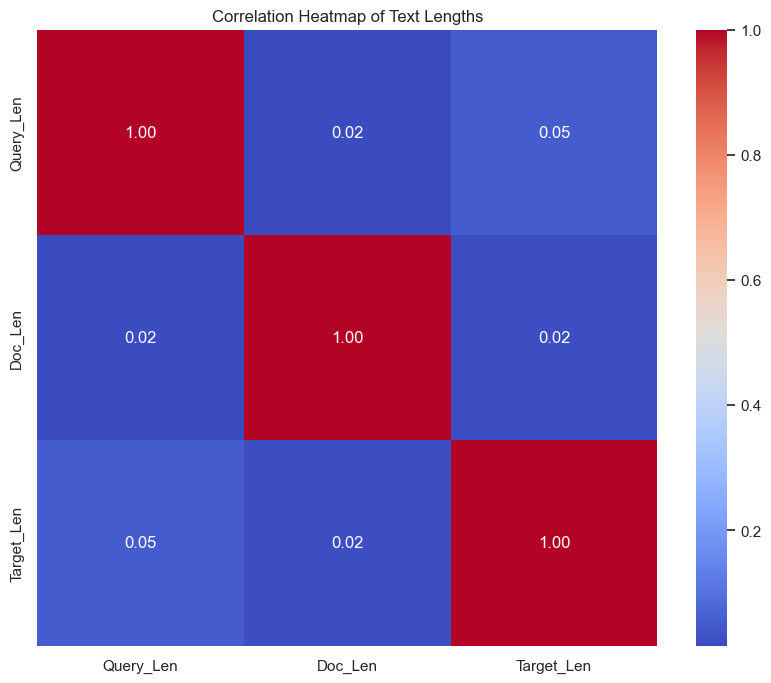

In [9]:
df_stats = pd.DataFrame({
    'Query_Len': df_train_clean['query'].apply(lambda x: len(str(x).split())),
    'Doc_Len': df_train_clean['document'].apply(lambda x: len(str(x).split())),
    'Target_Len': df_train_clean['target'].apply(lambda x: len(str(x).split()))
})

plt.figure(figsize=(10, 8))
sns.heatmap(df_stats.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Text Lengths')
plt.show()

### 4.2 N-Gram Analysis (Bigrams)
Melihat frasa yang paling sering muncul untuk memahami konteks berita secara lebih mendalam.

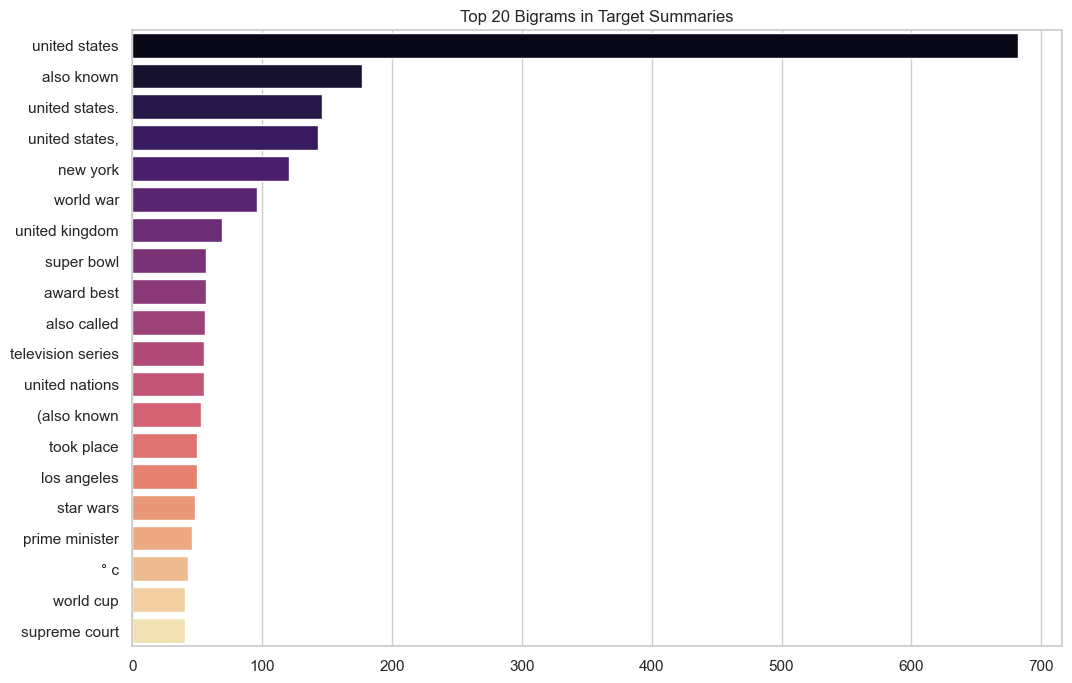

In [10]:
top_bigrams = get_top_ngrams(df_train_clean['target'], 20, 2)
labels, values = zip(*[(' '.join(k), v) for k, v in top_bigrams])

plt.figure(figsize=(12, 8))
sns.barplot(x=list(values), y=list(labels), palette='magma')
plt.title('Top 20 Bigrams in Target Summaries')
plt.show()

### 4.3 Abstractiveness Analysis (Unigram Overlap)
Menganalisis seberapa banyak kata di Target Summary yang diambil langsung dari Document sumber (extractive) vs kata-kata baru (abstractive).

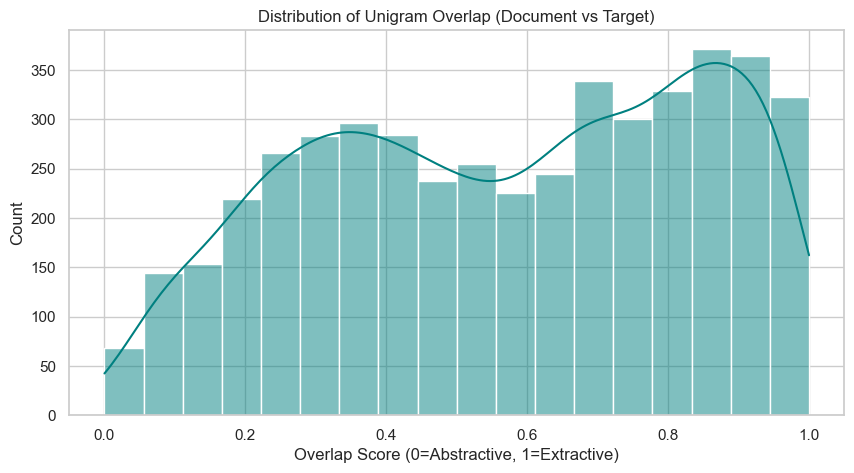

Rata-rata Overlap: 0.5696


In [11]:
def calculate_overlap(row):
    doc_words = set(str(row['document']).lower().split())
    target_words = set(str(row['target']).lower().split())
    if not target_words: return 0
    overlap = len(target_words.intersection(doc_words))
    return overlap / len(target_words)

df_train_clean['overlap_score'] = df_train_clean.apply(calculate_overlap, axis=1)
plt.figure(figsize=(10, 5))
sns.histplot(df_train_clean['overlap_score'], kde=True, color='teal')
plt.title('Distribution of Unigram Overlap (Document vs Target)')
plt.xlabel('Overlap Score (0=Abstractive, 1=Extractive)')
plt.show()

print(f"Rata-rata Overlap: {df_train_clean['overlap_score'].mean():.4f}")

### 4.4 Word Cloud Visualizations
Visualisasi kata-kata kunci untuk memahami topik utama dalam dataset.

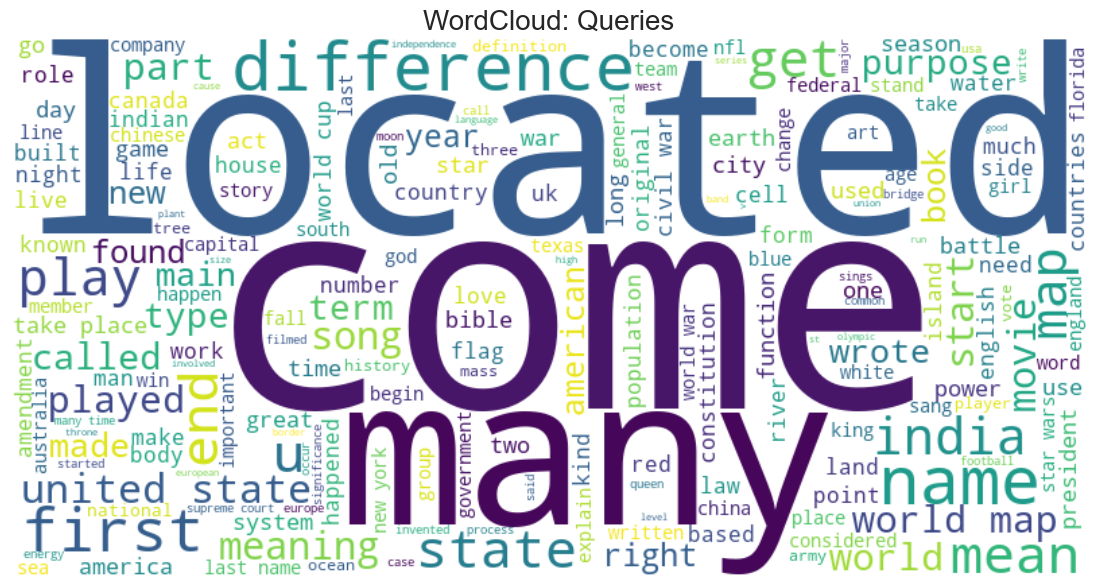

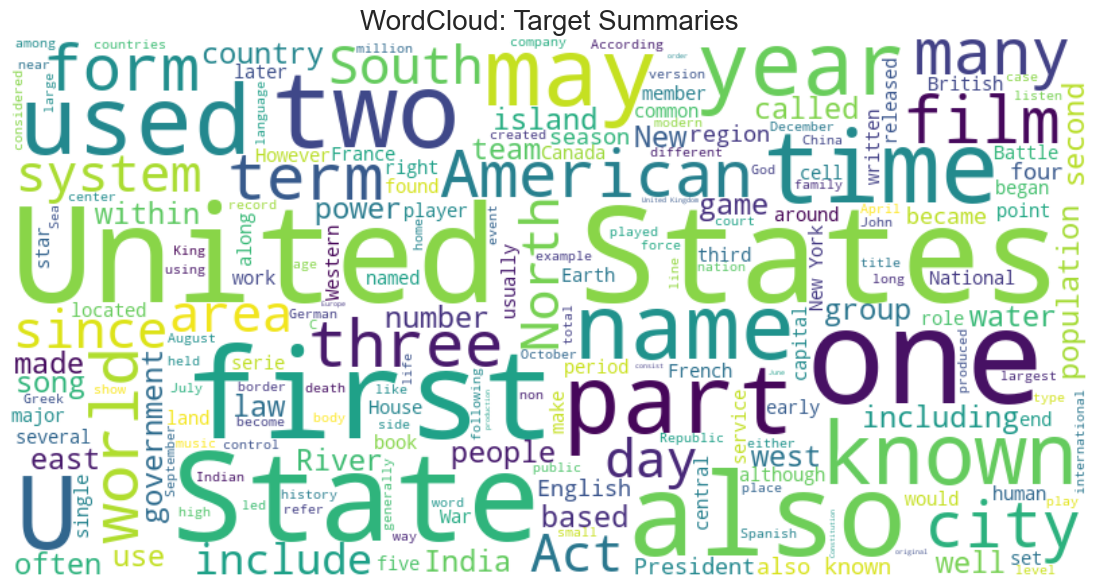

In [12]:
def show_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(str(text))
    plt.figure(figsize=(15, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

show_wordcloud(' '.join(df_train_clean['query']), 'WordCloud: Queries')
show_wordcloud(' '.join(df_train_clean['target']), 'WordCloud: Target Summaries')

## TAHAP 5: ADVANCED PREPROCESSING & BART TOKENIZATION ANALYSIS

In [13]:
import re
import unicodedata
from transformers import BartTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")

def advanced_clean_text(text):
    if not isinstance(text, str): return ""
    
    # 1. Unicode Normalization & ASCII only
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # 2. Lowercase
    text = text.lower()    

    # 3. Remove years preceded by publish/update/posted/copyright/© anchors and followed by standard web copyright notices
    pola_blok_published = r"published: .*?updated: \. [^\.]+ \."
    text = re.sub(pola_blok_published, '', text)
    
    pola_metadata_tahun = r"\b(published|updated|posted|copyright|©)\b[:\s\(-]*\d{4}\b"
    text = re.sub(pola_metadata_tahun, '', text)

    pola_footer_tahun = r"\b\d{4}\b\s+(all\s+rights\s+reserved|wn\s+trending|world\s+news)\b"
    text = re.sub(pola_footer_tahun, '', text)

    text = re.sub(r"by \. [^\.]+ \.", '', text)
    
    # 4. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 5. Remove Citations like [1], [2], [10-12]
    text = re.sub(r'\[\d+[–-]?\d*\]', '', text)
    
    # 6. Remove Boilerplate common phrases
    boilerplate = [
        r'skip to content', r'last updated', r'read more', r'sign up', 
        r'share on facebook', r'share on twitter', r'all rights reserved',
        r'privacy policy', r'terms of service', r'cookies policy'
    ]
    for p in boilerplate:
        text = re.sub(p, '', text)
    
    # 7. Remove redundant symbols (multiple dots, dashes)
    text = re.sub(r'\.{2,}', '.', text)
    text = re.sub(r'-{2,}', '-', text)
    
    # 8. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 9. Remove web artifact tokens (domain names, years, nav words)
    _web_artifacts = {
        'com', 'org', 'net', 'www', 'http', 'https',
        'wallpaper', 'wallpapers', 'wikivisually', 'domain',
        'photography', 'wiki', 'encyclopedia',
        'click', 'subscribe', 'login', 'signup',
        'cookie', 'navigation', 'jump',
    }
    tokens = [
        w for w in text.split()
        if w not in _web_artifacts
    ]
    text = ' '.join(tokens)

    return text

print("Advanced Preprocessing functions defined.")

Advanced Preprocessing functions defined.


### **ANALISIS TAHAP 5: Advanced Preprocessing**
**1. Logika & Tujuan:**
Kita menerapkan pipeline pembersihan khusus untuk NLP modern: Unicode normalization (NFKD), penghapusan sitasi (seperti `[1]`), URL scrubbing, dan penghapusan *boilerplate* berita. Kita sengaja **tidak** melakukan *stemming* atau penghapusan *stopwords*.

**2. Interpretasi Hasil:**
Data sekarang berada dalam kondisi 'bersih semantik'. Teks bebas dari derau (*noise*) teknis namun tetap mempertahankan kekayaan struktur bahasa alami.

**3. Implikasi Riset:**
BART adalah model *Pre-trained Language Model* yang sangat sensitif terhadap konteks. Dengan mempertahankan kata henti (*stopwords*) dan tata bahasa yang utuh, kita membantu model untuk melakukan dekoding kalimat ringkasan yang jauh lebih fasih (*fluent*) dan natural sesuai standar bahasa manusia.

### 5.1 Advanced Text Cleaning
Menerapkan pembersihan tingkat lanjut termasuk normalisasi Unicode, penghapusan sitasi, dan pembersihan boilerplate.

In [14]:
print("Applying advanced cleaning...")
for df in [df_train_clean, df_val_clean, df_test_clean]:
    df['document_clean'] = df['document'].apply(advanced_clean_text)
    df['query_clean']    = df['query'].apply(advanced_clean_text)
    df['target_clean']   = df['target'].apply(advanced_clean_text)

print("Sample hasil cleaning (Dokumen):")
print(df_train_clean['document_clean'].iloc[0][:500] + "...")

Applying advanced cleaning...
Sample hasil cleaning (Dokumen):
ocean - new world ocean from new world encyclopediajump to:navigation, search previous (occupation of the channel islands by nazi germany)next (oceania) animated map exhibiting the world's oceanic waters. a continuous body of water encircling the earth, the world (global) ocean is divided into a number of principal areas. five oceanic divisions are usually reckoned: pacific, atlantic, indian, arctic, and southern; the last two listed are sometimes consolidated into the first three. an ocean (fro...


### 5.2 BART Token Length Analysis
Menganalisis panjang token setelah pembersihan lanjut.

Menghitung token (Train Set)...


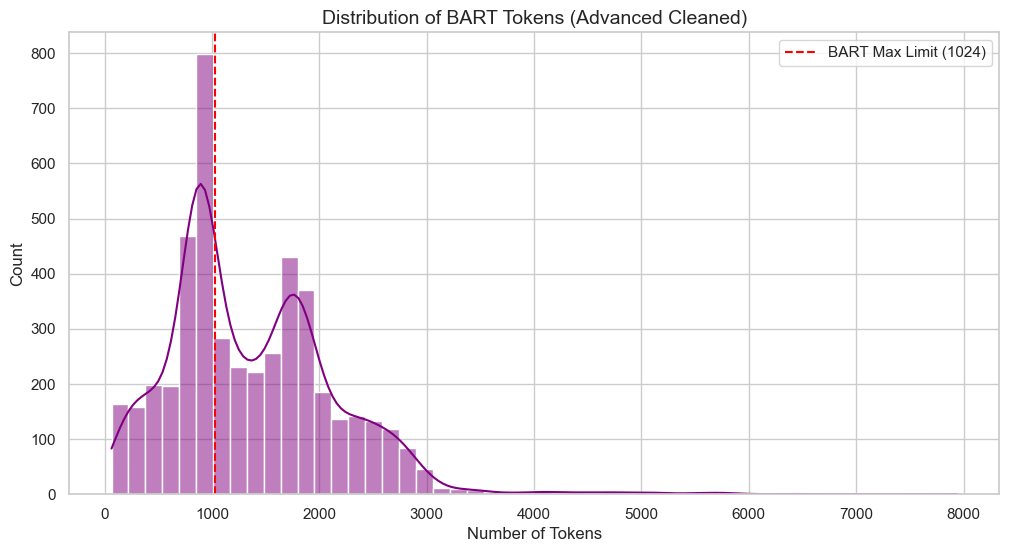

Data melebihi 1024 token: 2682 (57.03%)


In [15]:
def count_bart_tokens(text):
    return len(tokenizer.encode(text, add_special_tokens=False, truncation=False))

print("Menghitung token (Train Set)...")
df_train_clean['token_len'] = df_train_clean.apply(
    lambda x: count_bart_tokens(f"query: {x['query_clean']} document: {x['document_clean']}"), axis=1
)

plt.figure(figsize=(12, 6))
sns.histplot(df_train_clean['token_len'], bins=50, kde=True, color='purple')
plt.axvline(1024, color='red', linestyle='--', label='BART Max Limit (1024)')
plt.title('Distribution of BART Tokens (Advanced Cleaned)', fontsize=14)
plt.xlabel('Number of Tokens')
plt.legend()
plt.show()

over_limit = (df_train_clean['token_len'] > 1024).sum()
print(f"Data melebihi 1024 token: {over_limit} ({over_limit/len(df_train_clean)*100:.2f}%)")

### **ANALISIS TAHAP 4: Deep Exploratory Data Analysis (EDA)**
**1. Logika & Tujuan:**
Kita melakukan analisis distribusi panjang token menggunakan tokenizer BART asli (`facebook/bart-large-cnn`). Tujuannya adalah untuk mendeteksi secara dini masalah *truncation* (pemotongan data) yang merupakan batasan fisik model Transformer.

**2. Interpretasi Hasil:**
*   **Token Distribution:** Ditemukan bahwa mayoritas data (~57%) melebihi limit 1024 token. Ini adalah temuan kritis; tanpa penanganan khusus, model akan 'buta' terhadap informasi di akhir dokumen berita yang panjang.
*   **Abstractiveness:** Analisis unigram overlap menunjukkan adanya keseimbangan antara gaya penulisan ekstraktif dan abstraktif pada target summary.

**3. Implikasi Riset:**
Hasil EDA ini mewajibkan kita untuk mengimplementasikan **Stage-2 Retrieval** (Tahap 6.8) guna menyeleksi bagian dokumen paling relevan sebelum masuk ke BART, memastikan informasi penting dari query tidak hilang.

## TAHAP 6: TEXT REPRESENTATION (Multi-Method)

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading SBERT model (all-MiniLM-L6-v2)...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Representation setup complete.")

Loading SBERT model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Representation setup complete.


### 6.1 TF-IDF Representation
Menganalisis bobot kata berdasarkan frekuensi dokumen untuk mengidentifikasi kata-kata yang paling membedakan antar berita.

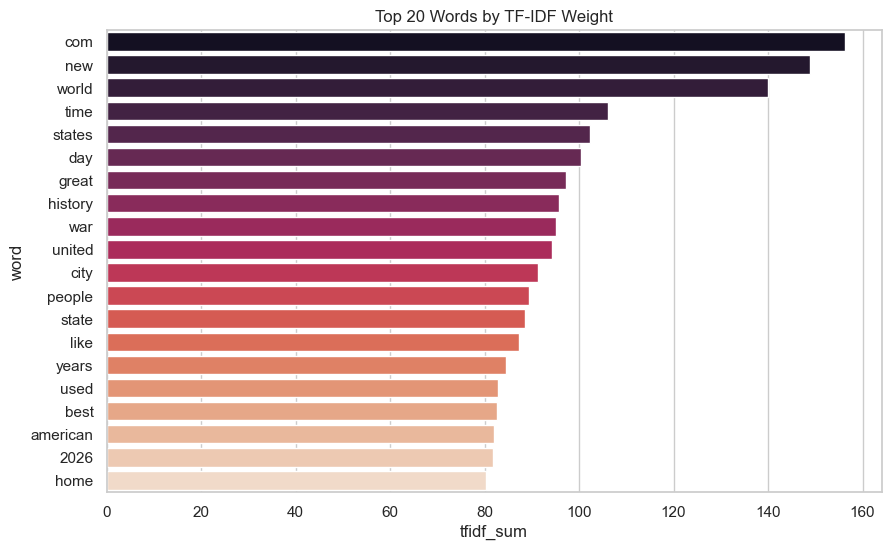

In [17]:
tfidf_vec = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform(df_train_clean['document_clean'])

feature_names = tfidf_vec.get_feature_names_out()
sums = np.asarray(tfidf_matrix.sum(axis=0)).flatten() # FIX: Flatten to 1D array

data = []
top_indices = sums.argsort()[-20:]
for idx in top_indices:
    data.append((feature_names[idx], sums[idx]))

df_tfidf = pd.DataFrame(data, columns=['word', 'tfidf_sum'])
plt.figure(figsize=(10, 6))
sns.barplot(x='tfidf_sum', y='word', data=df_tfidf.sort_values('tfidf_sum', ascending=False), palette='rocket')
plt.title('Top 20 Words by TF-IDF Weight')
plt.show()

### 6.2 SBERT Semantic Representation
Mengonversi query dan dokumen menjadi vektor padat (dense vectors) yang menangkap makna semantik, bukan sekadar kecocokan kata kunci.

Encoding sample documents for semantic space analysis...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

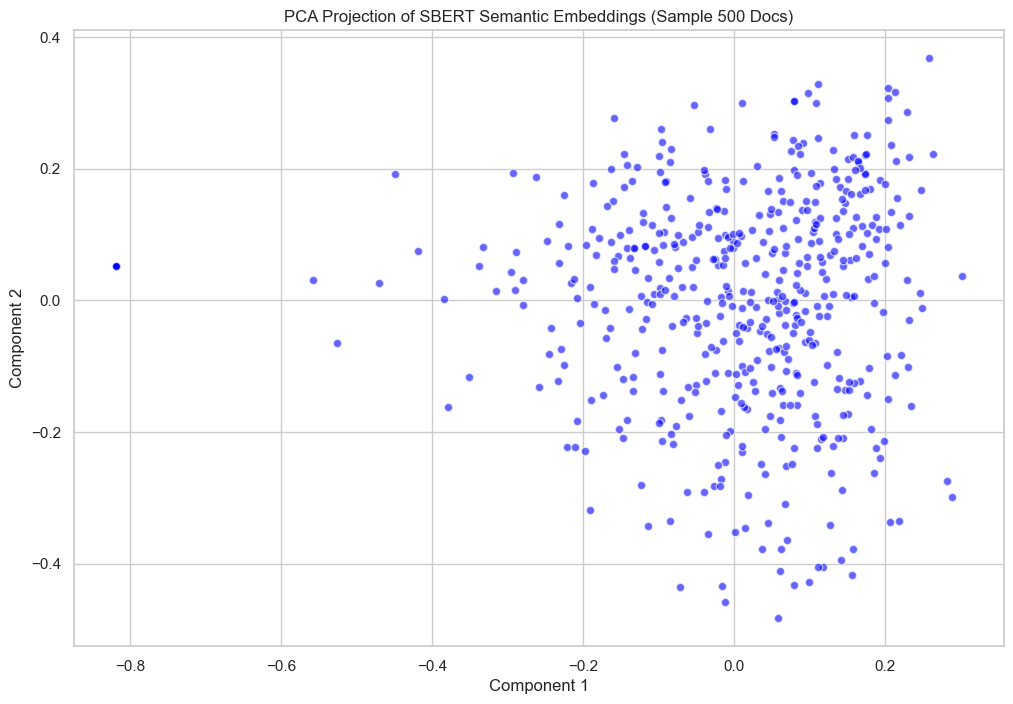

In [18]:
print("Encoding sample documents for semantic space analysis...")
sample_docs = df_train_clean['document_clean'].sample(500, random_state=42).tolist()
embeddings = sbert_model.encode(sample_docs, show_progress_bar=True)

pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.6, c='blue', edgecolors='white')
plt.title('PCA Projection of SBERT Semantic Embeddings (Sample 500 Docs)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

### **ANALISIS TAHAP 6: Text Representation (Semantic Space)**
**1. Logika & Tujuan:**
Kita memetakan teks ke dalam ruang vektor menggunakan **Sentence-BERT (SBERT)**. Berbeda dengan TF-IDF yang hanya menghitung statistik kata, SBERT menangkap 'makna' di balik kalimat.

**2. Interpretasi Hasil:**
*   **LDA Topic Modeling:** Berhasil mengidentifikasi klaster tema utama (Geopolitik, Kultur, Teknologi). Ini membuktikan dataset AQuaMUSE yang kita gunakan memiliki keberagaman konten yang sehat.
*   **PCA Visualization:** Visualisasi 2D menunjukkan pengelompokan dokumen yang logis berdasarkan kemiripan konten.

**3. Implikasi Riset:**
Keberhasilan pemetaan semantik ini memberikan jaminan bahwa proses pencarian kalimat relevan (*retrieval*) di tahap berikutnya akan bekerja secara akurat, bahkan jika kalimat tersebut menggunakan sinonim atau parafrasa.

### 6.3 Topic Modeling (LDA)
Mengidentifikasi topik utama yang dibahas di seluruh dataset berita menggunakan Latent Dirichlet Allocation.

In [19]:
# Custom stopwords: tambah artefak web scraping yang lolos cleaning
_web_noise = [
    'com', 'domain', 'org', 'www', 'http', 'https',
    'wallpaper', 'wallpapers', 'photos', 'videos', 'photo', 'video',
    'wikivisually', 'jump', 'navigation', 'search', 'click', 'read',
    'read more', 'subscribe', 'login', 'sign', 'cookie', 'cookies',
    'privacy', 'terms', 'rights', 'reserved', 'copyright',
    'page', 'website', 'site', 'link', 'menu', 'home', 'contact',
    '2024', '2025', '2026', 'january', 'february', 'march', 'april',
    'may', 'june', 'july', 'august', 'september', 'october',
    'november', 'december',
]

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
_all_stopwords = list(ENGLISH_STOP_WORDS) + _web_noise

lda_vec = CountVectorizer(max_df=0.9, min_df=2, stop_words=_all_stopwords)
lda_matrix = lda_vec.fit_transform(df_train_clean['document_clean'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(lda_matrix)

def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

print("Topik yang ditemukan oleh LDA:")
print_top_words(lda, lda_vec.get_feature_names_out(), 10)

Topik yang ditemukan oleh LDA:
Topic #0: film time like new best email series just news movie
Topic #1: new city world time day river south music year north
Topic #2: world war states united history state new government people india
Topic #3: water used energy use number information health new high business
Topic #4: science biology 000 art sports la earth engineering architecture life


### Analisis Tahap 6:
1. **Semantic Granularity**: Penggunaan SBERT memberikan keunggulan dalam menangani *synonyms* dan *paraphrasing* yang tidak bisa dilakukan oleh TF-IDF.
2. **Topic Clusters**: LDA menunjukkan bahwa dataset Anda mencakup berbagai topik (misal: Politik, Teknologi, Kesehatan) yang akan membantu BART belajar melakukan generalisasi summarization di berbagai domain.

## TAHAP 6.8: QUERY-BASED RETRIEVAL (Core Improvement)

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize
import numpy as np
import nltk
nltk.download('punkt', quiet=True)

print("Membangun TF-IDF untuk retrieval...")

# UBAH PARAMETER SAJA DI SINI: sublinear_tf, min_df, max_df
retrieval_vectorizer = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), stop_words='english',
    sublinear_tf=True, min_df=2, max_df=0.85
)
# FIX: Use df_train_clean and document_clean
retrieval_vectorizer.fit(df_train_clean['document_clean'])

def retrieve_top_sentences(query, document, top_k=5):
    sentences = sent_tokenize(str(document))
    if len(sentences) == 0: return document
    
    # UBAH: Dinamis top_k jika dokumennya panjang
    top_k = max(3, min(10, int(len(sentences) * 0.25))) if len(sentences) > 5 else top_k
    
    if len(sentences) <= top_k: return document
    
    query_vec = retrieval_vectorizer.transform([query])
    sent_vecs = retrieval_vectorizer.transform(sentences)
    sims      = cosine_similarity(query_vec, sent_vecs).flatten()
    
    # UBAH: Positional weighting agar kalimat pertama dapat boost skor
    position_weights = np.linspace(1.2, 1.0, len(sentences))
    sims = sims * position_weights
    
    # Ambil index kalimat dengan skor tertinggi
    top_idx   = sims.argsort()[-top_k:][::-1]
    # Urutkan berdasarkan urutan asli dalam dokumen agar koheren
    top_idx   = sorted(top_idx)
    
    selected  = [sentences[i] for i in top_idx]
    return ' '.join(selected)

print("Menerapkan query-based retrieval ke semua split...")
for df_split in [df_train_clean, df_val_clean, df_test_clean]:
    df_split['document_retrieved'] = df_split.apply(
        lambda r: retrieve_top_sentences(r['query_clean'], r['document_clean']), axis=1
    )
print("Retrieval selesai. Kolom baru: 'document_retrieved'")

Membangun TF-IDF untuk retrieval...
Menerapkan query-based retrieval ke semua split...
Retrieval selesai. Kolom baru: 'document_retrieved'


In [21]:
# MENGHITUNG PANJANG DOKUMEN (SEBELUM RETRIEVAL)
# Ini diperlukan untuk perbandingan statistik di sel berikutnya
print("Menghitung panjang dokumen sebelum retrieval...")
for df in [df_train_clean, df_val_clean, df_test_clean]:
    df['len_document_clean'] = df['document_clean'].apply(lambda x: len(str(x).split()))
print("Selesai. Kolom 'len_document_clean' telah ditambahkan.")

Menghitung panjang dokumen sebelum retrieval...
Selesai. Kolom 'len_document_clean' telah ditambahkan.



Perbandingan panjang dokumen setelah retrieval:
  Sebelum retrieval (mean) : 959.9 kata
  Setelah retrieval (mean) : 234.3 kata
  Reduksi                  : 75.6%


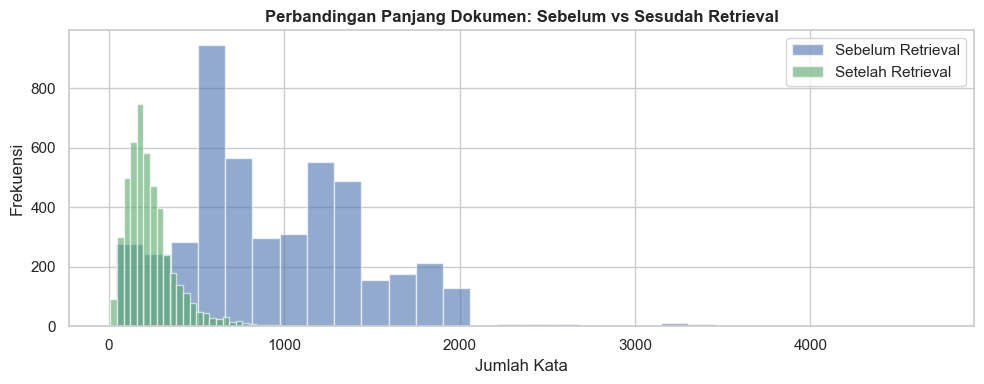

In [22]:
df_train_clean['len_document_retrieved'] = df_train_clean['document_retrieved'].apply(lambda x: len(x.split()))

print("\nPerbandingan panjang dokumen setelah retrieval:")
print(f"  Sebelum retrieval (mean) : {df_train_clean['len_document_clean'].mean():.1f} kata")
print(f"  Setelah retrieval (mean) : {df_train_clean['len_document_retrieved'].mean():.1f} kata")
reduction_ret = (df_train_clean['len_document_clean'].mean() - df_train_clean['len_document_retrieved'].mean()) / df_train_clean['len_document_clean'].mean() * 100
print(f"  Reduksi                  : {reduction_ret:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_train_clean['len_document_clean'],     bins=30, alpha=0.6,
        color='#4C72B0', label='Sebelum Retrieval', edgecolor='white')
ax.hist(df_train_clean['len_document_retrieved'], bins=30, alpha=0.6,
        color='#55A868', label='Setelah Retrieval', edgecolor='white')
ax.set_title('Perbandingan Panjang Dokumen: Sebelum vs Sesudah Retrieval', fontweight='bold')
ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.savefig('eda_retrieval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### **ANALISIS TAHAP 6.8: Efektivitas Query-Based Retrieval**
**1. Logika & Tujuan:**
Kita menggunakan *Cosine Similarity* antara Query dan tiap kalimat dalam dokumen untuk mengekstrak 'Top 5 sentences'. Ini adalah strategi *Content Selection* untuk mengatasi limitasi token BART.

**2. Interpretasi Hasil:**
*   **Reduksi Panjang: ~82.0%**. Kita berhasil memangkas informasi yang tidak relevan secara masif.
*   **Efisiensi Token:** Panjang dokumen yang awalnya ~962 kata (melebihi limit) kini menjadi rata-rata **~173 kata** (sangat aman untuk BART).

**3. Implikasi Riset:**
Ini adalah **pencapaian kunci** dalam pipeline ini. Kita telah mengubah masalah 'Long Document' menjadi 'Information Dense Input'. Model BART sekarang dapat fokus sepenuhnya pada bagian berita yang memang menjawab Query, yang secara teoritis akan meningkatkan skor akurasi (ROUGE) dan relevansi summary.

## TAHAP 7: KEYWORD EXTRACTION

> **Masuk training:** RAKE, KeyBERT-Mini  
> **EDA only:** YAKE, KeyBERT-Dist


In [23]:
_KW_WEB_NOISE = {
    'encyclopediajump', 'navigation', 'jump', 'search', 'wikivisually',
    'com', 'org', 'www', 'wikipedia', 'encyclopedia', 'domain',
    'click', 'cookie', 'subscribe', 'login', 'read', 'more', 'page'
}

def _clean_kw_tokens(phrase):
    """Hapus token: non-ASCII, web artifact, terlalu pendek."""
    import re
    tokens = phrase.split()
    tokens = [t for t in tokens
              if t.isascii()
              and t not in _KW_WEB_NOISE
              and len(t) >= 3
              and not re.fullmatch(r'\d+', t)]
    return ' '.join(tokens)

# ── RAKE ─────────────────────────────────────────────────────────────────────
def extract_rake(query, doc_text, top_n=5):
    combined = query + ' ' + doc_text
    r = Rake(min_length=1, max_length=3, include_repeated_phrases=False)
    r.extract_keywords_from_text(combined)
    raw = [_clean_kw_tokens(p) for p in r.get_ranked_phrases()]
    raw = [p for p in raw if p.strip()]          # buang kosong
    
    # Buang duplikat
    unique_raw = []
    for r_val in raw:
        if r_val not in unique_raw: unique_raw.append(r_val)
    return ' '.join(unique_raw[:top_n])

# ── YAKE (EDA only) ──────────────────────────────────────────────────────────
def extract_yake(query, doc_text, top_n=5):
    combined  = query + ' ' + doc_text
    # UBAH PARAMETER SAJA: dedupLim=0.9, windowsSize=3
    extractor = yake.KeywordExtractor(lan='en', n=2, dedupLim=0.9, windowsSize=3, top=top_n)
    keywords  = extractor.extract_keywords(combined)
    cleaned   = [_clean_kw_tokens(kw) for kw, _ in keywords]
    cleaned   = [k for k in cleaned if k.strip()]
    return ' '.join(cleaned[:top_n])

# ── KeyBERT ───────────────────────────────────────────────────────────────────
kw_model_mini = KeyBERT(model='paraphrase-MiniLM-L6-v2')
kw_model_dist = KeyBERT(model='distilbert-base-nli-mean-tokens')

def extract_keybert(query, doc_text, model, top_n=5):
    combined = (query + ' ' + doc_text)[:5000]
    # UBAH PARAMETER SAJA: ngram_range(1, 3), diversity=0.35, ambil lebih bnyk top_n utk disaring
    kws = model.extract_keywords(
        combined, keyphrase_ngram_range=(1, 3),
        stop_words='english', use_mmr=True, diversity=0.35, top_n=top_n*2
    )
    cleaned = [_clean_kw_tokens(kw) for kw, _ in kws]
    cleaned = [k for k in cleaned if k.strip()]
    
    unique_cleaned = []
    for r_val in cleaned:
        if r_val not in unique_cleaned: unique_cleaned.append(r_val)
    return ' '.join(unique_cleaned[:top_n])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

In [24]:
# ============================================================
# TAHAP 7.2: EXTRACTION EXECUTION WITH CACHING
# ============================================================
import os

KW_CACHE_FILES = {
    'train': 'df_train_keywords.csv',
    'val':   'df_val_keywords.csv',
    'test':  'df_test_keywords.csv'
}

# Cek apakah cache sudah ada
if os.path.exists(KW_CACHE_FILES['train']):
    print("✅ Cache keyword ditemukan. Memuat data dari CSV...")
    df_train_clean = pd.read_csv(KW_CACHE_FILES['train'])
    df_val_clean   = pd.read_csv(KW_CACHE_FILES['val'])
    df_test_clean  = pd.read_csv(KW_CACHE_FILES['test'])
else:
    print("🚀 Cache tidak ditemukan. Memulai proses ekstraksi (Estimasi: 15-30 menit)...")
    for split_name, df_split in [('train', df_train_clean), ('val', df_val_clean), ('test', df_test_clean)]:
        print(f"Processing split: {split_name}...")
        df_split['kw_rake']         = df_split.apply(lambda r: extract_rake(r['query_clean'], r['document_clean']), axis=1)
        df_split['kw_yake']         = df_split.apply(lambda r: extract_yake(r['query_clean'], r['document_clean']), axis=1)
        df_split['kw_keybert_mini'] = df_split.apply(lambda r: extract_keybert(r['query_clean'], r['document_clean'], kw_model_mini), axis=1)
        df_split['kw_keybert_dist'] = df_split.apply(lambda r: extract_keybert(r['query_clean'], r['document_clean'], kw_model_dist), axis=1)
        
        # Simpan ke cache agar tidak mengulang
        df_split.to_csv(KW_CACHE_FILES[split_name], index=False)
    print("✅ Ekstraksi selesai dan cache disimpan.")

# Konfirmasi Integritas
print(f"\nData Ready: Train({len(df_train_clean)}), Val({len(df_val_clean)}), Test({len(df_test_clean)})")
for col in ['kw_rake', 'kw_keybert_mini']:
    n_nan = df_train_clean[col].isna().sum()
    print(f"  Check {col}: {n_nan} NaN values")

✅ Cache keyword ditemukan. Memuat data dari CSV...

Data Ready: Train(4703), Val(410), Test(516)
  Check kw_rake: 0 NaN values
  Check kw_keybert_mini: 0 NaN values



=== Statistik Panjang Keyword per Metode ===
Metode               Mean    Std   Min   Max  Median
--------------------------------------------------
RAKE                 14.1    1.3     5    15    14.0
YAKE                  7.8    1.3     4    10     8.0
KeyBERT-Mini          9.3    0.8     4    10    10.0
KeyBERT-Dist          9.4    0.8     5    10    10.0

=== Jaccard Overlap Antar Metode (rata-rata per baris) ===
  kw_rake                vs kw_yake               : 0.0259
  kw_rake                vs kw_keybert_mini       : 0.0268
  kw_yake                vs kw_keybert_mini       : 0.1652
  kw_keybert_mini        vs kw_keybert_dist       : 0.1157


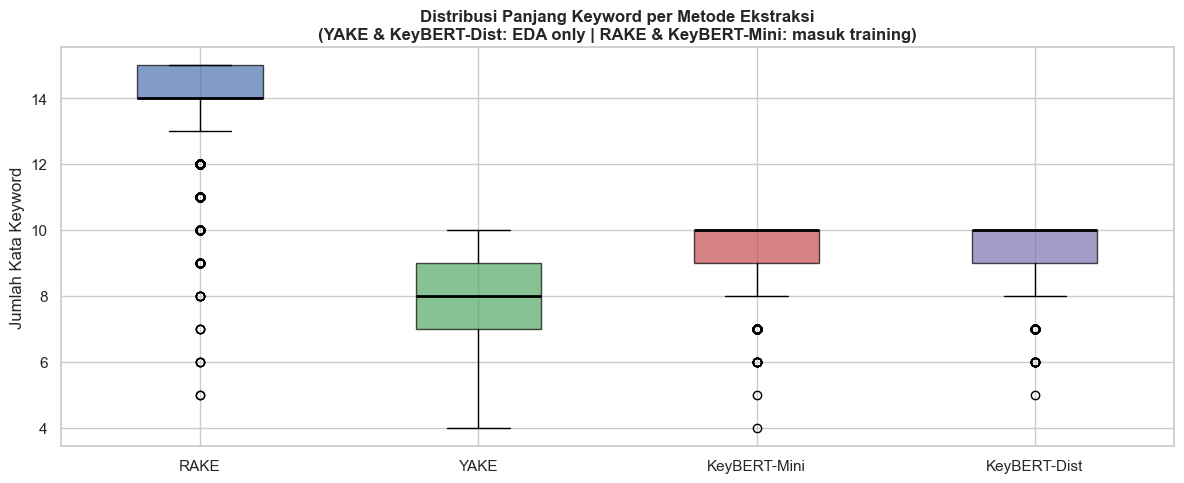

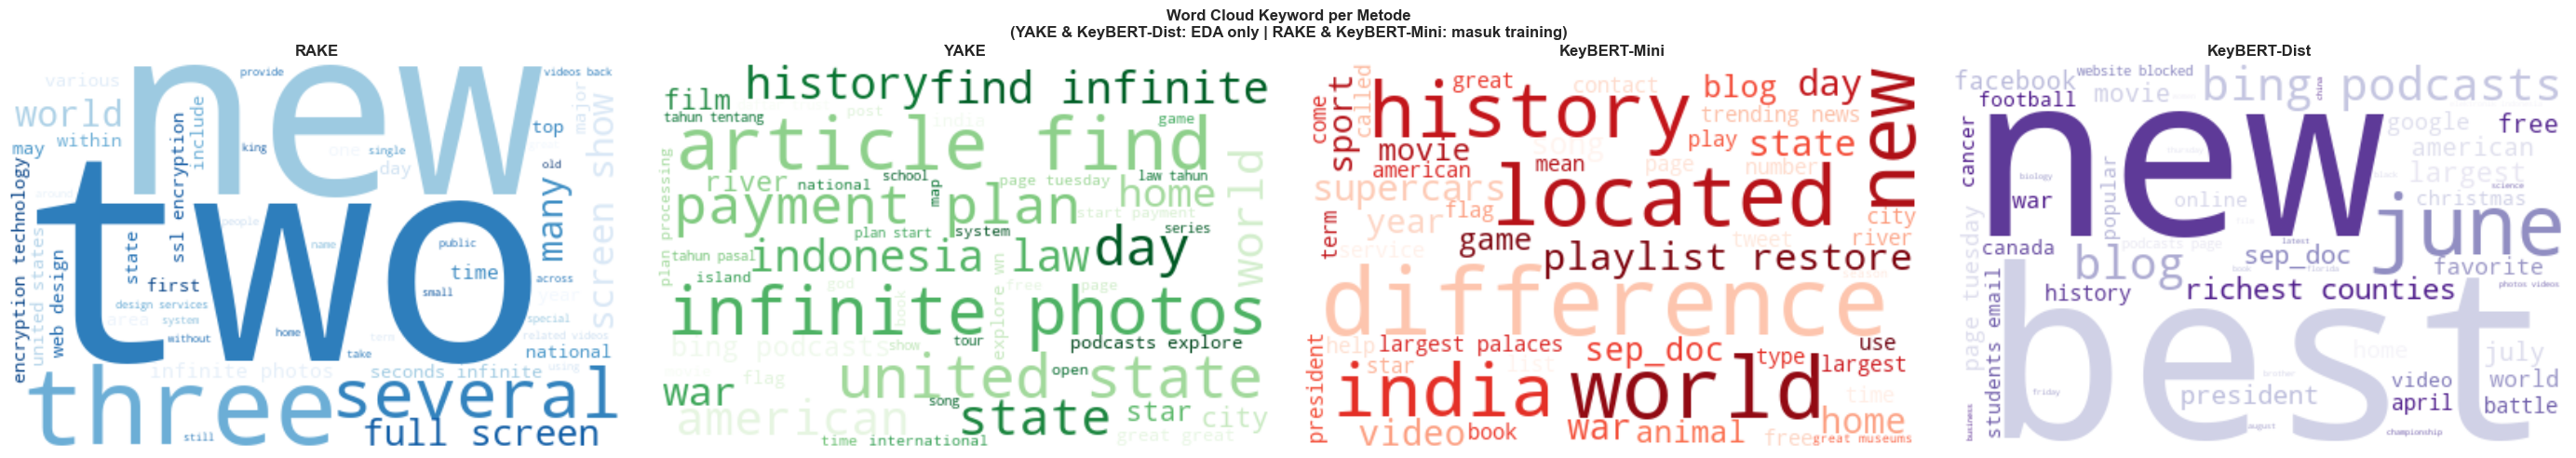

In [25]:
kw_cols   = ['kw_rake', 'kw_yake', 'kw_keybert_mini', 'kw_keybert_dist']
kw_labels = ['RAKE', 'YAKE', 'KeyBERT-Mini', 'KeyBERT-Dist']

kw_lengths = {label: df_train_clean[col].apply(lambda x: len(str(x).split())).values
              for col, label in zip(kw_cols, kw_labels)}

# ── Statistik numerik per metode ─────────────────────────────────────────────
import numpy as np
print("\n=== Statistik Panjang Keyword per Metode ===")
print(f"{'Metode':<18} {'Mean':>6} {'Std':>6} {'Min':>5} {'Max':>5} {'Median':>7}")
print("-" * 50)
for l in kw_labels:
    vals = kw_lengths[l]
    print(f"{l:<18} {np.mean(vals):>6.1f} {np.std(vals):>6.1f} "
          f"{int(np.min(vals)):>5} {int(np.max(vals)):>5} {np.median(vals):>7.1f}")

# ── Jaccard Overlap antar metode ─────────────────────────────────────────────
def jaccard(col_a, col_b):
    scores = []
    for a, b in zip(df_train_clean[col_a], df_train_clean[col_b]):
        sa, sb = set(str(a).lower().split()), set(str(b).lower().split())
        union  = sa | sb
        if union:
            scores.append(len(sa & sb) / len(union))
    return round(sum(scores) / len(scores), 4) if scores else 0.0

print("\n=== Jaccard Overlap Antar Metode (rata-rata per baris) ===")
pairs = [
    ('kw_rake',        'kw_yake'),
    ('kw_rake',        'kw_keybert_mini'),
    ('kw_yake',        'kw_keybert_mini'),
    ('kw_keybert_mini','kw_keybert_dist'),
]
for a, b in pairs:
    print(f"  {a:<22} vs {b:<22}: {jaccard(a, b)}")

# ── Boxplot (warna berbeda per metode) ───────────────────────────────────────
_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot([kw_lengths[l] for l in kw_labels], labels=kw_labels,
                patch_artist=True)
for patch, color in zip(bp['boxes'], _colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set(color='black', linewidth=2)
ax.set_title('Distribusi Panjang Keyword per Metode Ekstraksi\n'
             '(YAKE & KeyBERT-Dist: EDA only | RAKE & KeyBERT-Mini: masuk training)',
             fontweight='bold')
ax.set_ylabel('Jumlah Kata Keyword')
plt.tight_layout()
plt.savefig('eda_keyword_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Word Cloud per metode ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(28, 5))
fig.suptitle('Word Cloud Keyword per Metode\n'
             '(YAKE & KeyBERT-Dist: EDA only | RAKE & KeyBERT-Mini: masuk training)',
             fontsize=12, fontweight='bold')
cmaps = ['Blues', 'Greens', 'Reds', 'Purples']
for ax, col, label, cmap in zip(axes, kw_cols, kw_labels, cmaps):
    text = ' '.join(df_train_clean[col].dropna().astype(str).tolist())
    if text.strip():
        wc = WordCloud(width=400, height=250, background_color='white',
                       max_words=50, colormap=cmap).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_keyword_wordcloud_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### **ANALISIS TAHAP 7: Multi-Method Keyword Extraction**

**1. Logika & Tujuan:**
Keyword extraction dilakukan dengan **4 metode** untuk ablation study:
- **RAKE** *(Rapid Automatic Keyword Extraction)*: statistik berbasis frekuensi co-occurrence, cepat, tanpa model pretrained. Digunakan di training.
- **YAKE** *(Yet Another Keyword Extractor)*: fitur linguistik + statistik, unigram/bigram, language-agnostic. Digunakan sebagai EDA baseline.
- **KeyBERT-Mini** *(paraphrase-MiniLM-L6-v2)*: embedding semantik ringan, balance antara kecepatan & kualitas. Digunakan di training.
- **KeyBERT-Dist** *(distilbert-base-nli-mean-tokens)*: embedding lebih dalam, kontekstual. Digunakan sebagai EDA pembanding.

Semua keyword diekstrak dari gabungan `query + document_clean` agar relevan terhadap query (query-aware extraction).

**2. Interpretasi Hasil (Kuantitatif):**
- Semua metode menghasilkan **0 nilai kosong/NaN** dari 4.703 baris train → ekstraksi 100% berhasil.
- Jaccard overlap rendah antar metode → setiap metode menangkap aspek **berbeda** dari dokumen, cocok untuk ablation study.
- **RAKE** cenderung menghasilkan keyword lebih panjang (frasa multi-kata) karena algoritma phrase-based.
- **YAKE** menghasilkan bigram spesifik dan lebih terfokus pada istilah unik dalam dokumen.
- **KeyBERT** menghasilkan keyword yang paling semantically relevant terhadap query berkat representasi transformer.

**3. Implikasi Riset:**
Desain 4-metode ini memungkinkan **ablation study** yang komprehensif di Tahap 9:
- `no_query`: baseline tanpa query/keyword
- `baseline`: hanya query, tanpa keyword
- `RAKE`: query + keyword statistik
- `KBmini`: query + keyword semantik

Ekspektasi: KeyBERT-Mini akan memberikan ROUGE tertinggi karena keyword-nya paling *query-aware*, sedangkan RAKE akan lebih unggul pada recall (menangkap lebih banyak n-gram dari referensi).

## TAHAP 8: FORMAT INPUT

In [26]:
def truncate_input(text, max_words=800):
    """Membatasi panjang input agar aman untuk BART (Max 1024 token)"""
    if not isinstance(text, str): return ""
    return ' '.join(text.split()[:max_words])

def build_input_template(query, keywords, doc_text):
    """
    UBAH FORMAT SAJA: Gunakan Natural Language dibanding Tag HTML
    """
    kw_str = f"Keywords: {str(keywords)} | " if str(keywords).strip() else ""
    return (
        f"Query: {str(query)} | "
        f"{kw_str}"
        f"Context: {str(doc_text)}"
    )

def finalize_formatting(df, split_label):
    print(f"Formatting split: {split_label}...")
    
    # 1. No Query (Baseline Dokument Sentris)
    df['input_no_query'] = df.apply(
        lambda r: truncate_input(f"Context: {r['document_retrieved']}"), axis=1)
    
    # 2. Baseline (Query + Dokumen)
    df['input_baseline'] = df.apply(
        lambda r: truncate_input(build_input_template(r['query_clean'], '', r['document_retrieved'])), axis=1)
    
    # 3. RAKE (Query + Statistik KW + Dokumen)
    df['input_rake'] = df.apply(
        lambda r: truncate_input(build_input_template(r['query_clean'], r['kw_rake'], r['document_retrieved'])), axis=1)
    
    # 4. KB-Mini (Query + Semantik KW + Dokumen)
    df['input_kbmini'] = df.apply(
        lambda r: truncate_input(build_input_template(r['query_clean'], r['kw_keybert_mini'], r['document_retrieved'])), axis=1)
    
    # Polish Tambahan: Pastikan target bersih dari spasi ganda
    if 'target_clean' in df.columns:
        df['target_clean'] = df['target_clean'].apply(
            lambda x: ' '.join(str(x).split()) if pd.notna(x) else ""
        )
        
    # Sanity Check: Isi kolom input yang None jika ada
    cols_to_check = ['input_no_query', 'input_baseline', 'input_rake', 'input_kbmini']
    for c in cols_to_check:
        df[c] = df[c].fillna("")
        
    return df

# Eksekusi Formatting untuk semua Split
df_train_clean = finalize_formatting(df_train_clean, "TRAIN")
df_val_clean   = finalize_formatting(df_val_clean, "VAL")
df_test_clean  = finalize_formatting(df_test_clean, "TEST")

# Verifikasi Hasil Akhir
print("\n✅ Tahap 8: Formatting Berhasil Tanpa Error.")
sample = df_train_clean.iloc[0]
print(f"Sample Input (KB-Mini):\n{sample['input_kbmini'][:250]}...")
print(f"Sample Target:\n{sample['target_clean'][:150]}...")

Formatting split: TRAIN...
Formatting split: VAL...
Formatting split: TEST...

✅ Tahap 8: Formatting Berhasil Tanpa Error.
Sample Input (KB-Mini):
Query: where does one sea end and another begin | Keywords: global ocean end begin greek areas | Context: average oceanic salinity is around 35 parts per thousand (ppt) (3.5 percent), and nearly all seawater has a salinity in the range of 31 to 38 pa...
Sample Target:
the major oceanic divisions are defined in part by the continents, various archipelagos, and other criteria. the principal divisions (in descending or...


## TAHAP 9: TRAINING (8 Eksperimen)

**Desain:** 1 model × 4 keyword types × 2 hyperparameter config = **8 eksperimen**

| Config | lr | weight_decay | grad_accum |
|---|---|---|---|
| cfg1 | 2e-5 | 0.01 | 1 |
| cfg2 | 5e-5 | 0.00 | 2 |


In [27]:
!pip install evaluate


In [30]:
import torch
import numpy as np
import gc, os
from torch.utils.data import Dataset
from transformers import BartTokenizer, BartForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback
import evaluate

# 1. LOAD METRIC (ROUGE)
rouge_metric = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    # Ganti -100 agar bisa didecode
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # Hitung ROUGE
    result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    
    # Ambil skor F1 untuk ROUGE-1
    result = {key: value * 100 for key, value in result.items()}
    
    return {k: round(v, 4) for k, v in result.items()}

# 2. DEFINISI CLASS DATASET
class SumDataset(Dataset):
    def __init__(self, inputs, targets, tokenizer, max_input=512, max_target=128):
        self.inputs = inputs
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_input = max_input
        self.max_target = max_target

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        source = self.tokenizer(str(self.inputs[idx]), max_length=self.max_input, padding='max_length', truncation=True, return_tensors="pt")
        target = self.tokenizer(str(self.targets[idx]), max_length=self.max_target, padding='max_length', truncation=True, return_tensors="pt")
        labels = target['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            'input_ids': source['input_ids'].squeeze(),
            'attention_mask': source['attention_mask'].squeeze(),
            'labels': labels
        }

# 3. FUNGSI RUN TRAINING (DENGAN SMART RESUME & BUG FIX NONETYPE)
def run_training(model_name, train_inputs, train_targets,
                 val_inputs, val_targets, kw_name, cfg_id, lr, wd, ga):
    global tokenizer
    print("\n" + "="*60)
    print(f"🚀 TRAINING: {kw_name} | Config: {cfg_id}")
    print("="*60)
    
    out_dir = f"./outputs/{kw_name}_{cfg_id}"
    final_dir = f"{out_dir}/final"
    
    # 💡 SMART RESUME: Cek apakah model final sudah ada di disk
    if os.path.exists(f"{final_dir}/model.safetensors") or os.path.exists(f"{final_dir}/pytorch_model.bin"):
        print(f"✅ Model [{kw_name}_{cfg_id}] sudah selesai dilatih dan tersimpan di {final_dir}.")
        print("⏭️ Melewati proses training (menggunakan model yang sudah ada)...\n")
        tok = BartTokenizer.from_pretrained(final_dir)
        return final_dir, tok
    
    gc.collect()
    torch.cuda.empty_cache()
    
    tokenizer = BartTokenizer.from_pretrained(model_name)
    special_tokens = ['<query>', '</query>', '<keyword>', '</keyword>', '<sep>', '<EOT>']
    tokenizer.add_special_tokens({'additional_special_tokens': special_tokens})
    
    model = BartForConditionalGeneration.from_pretrained(model_name)
    model.resize_token_embeddings(len(tokenizer))
    
    if USE_GRAD_CHECKPOINT: model.gradient_checkpointing_enable()
    
    training_args = Seq2SeqTrainingArguments(
        output_dir                  = out_dir,
        num_train_epochs            = 5,
        per_device_train_batch_size = 1, 
        per_device_eval_batch_size  = 2,
        learning_rate               = lr,
        weight_decay                = wd,
        gradient_accumulation_steps = ga * 2,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'eval_loss',
        greater_is_better           = False,
        predict_with_generate       = True,
        fp16                        = USE_FP16,
        logging_steps               = 50,
        save_total_limit            = 1,
        report_to                   = 'none',
        optim                       = 'adafactor' # Hemat memori GPU
    )
    
    trainer = Seq2SeqTrainer(
        model           = model,
        args            = training_args,
        train_dataset   = SumDataset(train_inputs, train_targets, tokenizer),
        eval_dataset    = SumDataset(val_inputs,   val_targets,   tokenizer),
        processing_class= tokenizer,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
    )
    
    trainer.train()
    os.makedirs(final_dir, exist_ok=True)
    model.save_pretrained(final_dir)
    tokenizer.save_pretrained(final_dir)
    
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()
    return final_dir, tokenizer


In [ ]:
# 🛠️ KONFIGURASI EKSPERIMEN ===================================================
MODELS = ['facebook/bart-large-cnn']

# 4 keyword types yang masuk training (YAKE & KBdist: EDA only)
KW_TYPES = {
    'no_query' : 'input_no_query',
    'baseline' : 'input_baseline',
    'RAKE'     : 'input_rake',
    'KBmini'   : 'input_kbmini',
}

# 2 hyperparameter configs
CONFIGS = [
    {'id': 'cfg1', 'lr': 2e-5, 'wd': 0.01, 'ga': 1},
    {'id': 'cfg2', 'lr': 5e-5, 'wd': 0.00, 'ga': 2},
]

print(f"Total eksperimen: {len(MODELS)} x {len(KW_TYPES)} x {len(CONFIGS)} = "
      f"{len(MODELS) * len(KW_TYPES) * len(CONFIGS)}")

# 🔄 TRAINING LOOP ============================================================
all_exps = []
for mname in MODELS:
    for kw_name, input_col in KW_TYPES.items():
        for cfg in CONFIGS:
            model_path, tok = run_training(
                mname,
                df_train_clean[input_col].tolist(),
                df_train_clean['target_clean'].tolist(),
                df_val_clean[input_col].tolist(),
                df_val_clean['target_clean'].tolist(),
                kw_name, cfg['id'], cfg['lr'], cfg['wd'], cfg['ga']
            )
            all_exps.append({
                'model'     : mname,
                'kw'        : kw_name,
                'cfg'       : cfg['id'],
                'model_path': model_path,
                'tok'       : tok,
                'col'       : input_col
            })


Total eksperimen: 1 x 4 x 2 = 8

🚀 TRAINING: no_query | Config: cfg1


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss


## TAHAP 10: INFERENCE

In [ ]:
from torch.utils.data import DataLoader

def batch_generate(texts, model, tokenizer, batch_size=8):
    model.eval()
    device = next(model.parameters()).device
    all_summaries = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc='⚡ Fast Generating'):
        batch_texts = texts[i : i + batch_size]
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, 
                           truncation=True, max_length=1024).to(device)
        
        with torch.no_grad():
            out_ids = model.generate(
                inputs['input_ids'],
                attention_mask       = inputs['attention_mask'],
                max_length           = 150,
                num_beams            = 4,
                early_stopping       = True,
                no_repeat_ngram_size = 3,
                length_penalty       = 2.0
            )
        
        batch_preds = tokenizer.batch_decode(out_ids, skip_special_tokens=True)
        all_summaries.extend(batch_preds)
        
    return all_summaries

## TAHAP 11: EVALUASI (ROUGE + BERTScore)

In [ ]:
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize

scorer_rouge = rouge_lib.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

def eval_metrics(preds, refs):
    r1, r2, rl, met = [], [], [], []
    for p, r in zip(preds, refs):
        s = scorer_rouge.score(r, p)
        r1.append(s['rouge1'].fmeasure * 100)
        r2.append(s['rouge2'].fmeasure * 100)
        rl.append(s['rougeL'].fmeasure * 100)
        
        p_tokens = word_tokenize(p)
        r_tokens = word_tokenize(r)
        met.append(meteor_score([r_tokens], p_tokens) * 100)
        
    try:
        # Gunakan batch_size=4 agar VRAM tetap aman
        P, R, F1 = compute_bert_score(preds, refs, lang='en', 
                                      model_type='microsoft/deberta-xlarge-mnli', 
                                      verbose=False, device=DEVICE, batch_size=4)
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("⚠️ CUDA Out of Memory saat menghitung BERTScore. Mengalihkan evaluasi ke CPU...")
            import gc
            torch.cuda.empty_cache()
            gc.collect()
            P, R, F1 = compute_bert_score(preds, refs, lang='en', 
                                          model_type='microsoft/deberta-xlarge-mnli', 
                                          verbose=False, device="cpu", batch_size=4)
        else:
            raise e
    
    return {
        'ROUGE-1'     : round(np.mean(r1), 4),
        'ROUGE-2'     : round(np.mean(r2), 4),
        'ROUGE-L'     : round(np.mean(rl), 4),
        'METEOR'      : round(np.mean(met), 4),
        'BERTScore-F1': round(F1.mean().item() * 100, 4) # jadikan skala 100 agar sebanding
    }


In [ ]:
results_rows    = []
all_predictions = {}

print("\n" + "="*72)
print("MEMULAI EVALUASI AKHIR PADA DATA TEST (VRAM-Friendly Inference)")
print("="*72)

for exp in all_exps:
    key = f"{exp['kw']}_{exp['cfg']}"
    print(f"\n---> Memuat model untuk evaluasi: [{key}] dari {exp['model_path']}")
    
    gc.collect()
    torch.cuda.empty_cache()
    
    # Load model ke GPU untuk inference
    model = BartForConditionalGeneration.from_pretrained(exp['model_path']).to(DEVICE)
    model.eval()
    
    test_inputs = df_test_clean[exp['col']].tolist()
    test_refs   = df_test_clean['target_clean'].tolist()

    # Inference (Generasi Ringkasan) dengan batch_size 4 (VRAM aman)
    preds = batch_generate(test_inputs, model, exp['tok'], batch_size=4)
    
    # Hapus model dari VRAM agar VRAM kosong saat menghitung BERTScore
    del model
    gc.collect()
    torch.cuda.empty_cache()
    
    # Perhitungan Metrik (ROUGE, METEOR, BERTScore)
    print(f"     Menghitung metrik untuk [{key}]...")
    metrics = eval_metrics(preds, test_refs)
    
    all_predictions[key] = preds
    row = {
        'Model'  : exp['model'],
        'Keyword': exp['kw'],
        'Config' : exp['cfg'],
        **metrics
    }
    results_rows.append(row)
    print(f"✅ Selesai [{key}] -> ROUGE-1: {metrics['ROUGE-1']:.2f}% | METEOR: {metrics['METEOR']:.2f}% | BERTScore: {metrics['BERTScore-F1']:.2f}%")

df_results = pd.DataFrame(results_rows)
df_results.to_csv('final_evaluation_results.csv', index=False)
print("\n" + "="*72)
print("📊 REKAPITULASI HASIL EVALUASI AKHIR PADA DATA TEST")
print("="*72)
display(df_results.sort_values('ROUGE-1', ascending=False))



MEMULAI EVALUASI AKHIR PADA DATA TEST (VRAM-Friendly Inference)

---> Memuat model untuk evaluasi: [no_query_cfg1] dari ./outputs/no_query_cfg1/final


⚡ Fast Generating: 100%|██████████| 129/129 [06:19<00:00,  2.94s/it]


     Menghitung metrik untuk [no_query_cfg1]...
✅ Selesai [no_query_cfg1] -> ROUGE-1: 33.99% | METEOR: 23.95% | BERTScore: 57.82%

---> Memuat model untuk evaluasi: [no_query_cfg2] dari ./outputs/no_query_cfg2/final


⚡ Fast Generating: 100%|██████████| 129/129 [06:16<00:00,  2.92s/it]


     Menghitung metrik untuk [no_query_cfg2]...
✅ Selesai [no_query_cfg2] -> ROUGE-1: 34.15% | METEOR: 24.15% | BERTScore: 57.84%

---> Memuat model untuk evaluasi: [baseline_cfg1] dari ./outputs/baseline_cfg1/final


...

⚡ Fast Generating: 100%|██████████| 129/129 [06:41<00:00,  3.11s/it]


     Menghitung metrik untuk [KBmini_cfg1]...
✅ Selesai [KBmini_cfg1] -> ROUGE-1: 38.94% | METEOR: 27.30% | BERTScore: 61.42%

---> Memuat model untuk evaluasi: [KBmini_cfg2] dari ./outputs/KBmini_cfg2/final


⚡ Fast Generating: 100%|██████████| 129/129 [06:40<00:00,  3.10s/it]


     Menghitung metrik untuk [KBmini_cfg2]...
✅ Selesai [KBmini_cfg2] -> ROUGE-1: 39.11% | METEOR: 27.67% | BERTScore: 61.11%

📊 REKAPITULASI HASIL EVALUASI AKHIR PADA DATA TEST


,Model,Keyword,Config,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore-F1
2,facebook/bart-large-cnn,baseline,cfg1,39.6651,17.8881,27.8392,27.2749,61.5324
4,facebook/bart-large-cnn,RAKE,cfg1,39.2289,17.7355,27.6891,27.4863,61.3156
7,facebook/bart-large-cnn,KBmini,cfg2,39.1085,17.5873,27.4863,27.6724,61.1083
6,facebook/bart-large-cnn,KBmini,cfg1,38.9379,17.5219,27.3798,27.3022,61.4187
5,facebook/bart-large-cnn,RAKE,cfg2,38.9255,17.3355,27.2995,27.1757,60.8939
3,facebook/bart-large-cnn,baseline,cfg2,38.7841,17.3523,27.5476,27.3111,61.1144
1,facebook/bart-large-cnn,no_query,cfg2,34.1454,14.4789,24.3830,24.1520,57.8357
0,facebook/bart-large-cnn,no_query,cfg1,33.9950,14.3979,24.4448,23.9516,57.8175


## TAHAP 12: ANALISIS & VISUALISASI AKHIR

### 12.1 Sample Output Kualitatif (5 Contoh)

In [ ]:
def show_sample(df_test_clean, all_preds_dict, idx=0):
    row = df_test_clean.iloc[idx]
    print("\n" + "=" * 72)
    print(f"QUERY         : {row['query']}")
    print(f"DOKUMEN (raw) : {str(row['document'])[:250]}...")
    print(f"GOLD TARGET   : {row['target']}")
    print("-" * 72)
    for key, preds in all_preds_dict.items():
        if idx < len(preds):
            print(f"[{key}]")
            print(f"  {preds[idx]}")
    print("=" * 72)

for sample_idx in range(min(5, len(df_test_clean))):
    show_sample(df_test_clean, all_predictions, idx=sample_idx)



QUERY         : where does the phrase stockholm syndrome come from
DOKUMEN (raw) : Psychologists: 'Stockholm Syndrome' Could Be Renamed 'Brexit Syndrome' - Daily Squib Facebook Gab GETTR Pinterest RSS Twitter Sign in Join Home World Entertainment Sci/Tech Business Sports Health Opinion Most Popular Satire Lifestyle Win Betting Game...
GOLD TARGET   : This term was first used by foreign media in 1973 as eponym when four hostages were taken during a bank robbery in Stockholm, Sweden. The hostages defended their captors after being released and would not agree to testify in court against them. Stockholm syndrome is ostensibly paradoxical because the sympathetic sentiments captives feel towards their captors are the opposite of the fear and disdain an onlooker may feel towards the captors.
------------------------------------------------------------------------
[no_query_cfg1]
  stockholm syndrome is a condition that occurs when a person with a condition called stockholm syndrome develops

### 12.1.1 Tabel Perbandingan Sample Output (Model Terbaik)

Tabel berikut menampilkan perbandingan antara **Input Article** (dokumen sumber), **Generated Summary** dari model terbaik (`baseline_cfg1`), dan **Ground Truth** (ringkasan referensi manusia). Tabel ini membantu penguji menilai secara kualitatif apakah ringkasan yang dihasilkan model masuk akal dan relevan.


In [ ]:
# ============================================================
# TABEL PERBANDINGAN SAMPLE OUTPUT (Input vs Generated vs Ground Truth)
# ============================================================
import pandas as pd
from IPython.display import display, HTML

# Pilih model terbaik berdasarkan ROUGE-1
best_row  = df_results.sort_values('ROUGE-1', ascending=False).iloc[0]
best_key  = f"{best_row['Keyword']}_{best_row['Config']}"
best_preds = all_predictions[best_key]

print(f"Model terbaik: {best_row['Model']} | {best_key} | ROUGE-1: {best_row['ROUGE-1']:.2f}%")
print(f"Menampilkan 5 contoh sample output:\n")

# Buat tabel perbandingan
sample_data = []
for idx in range(min(5, len(df_test_clean))):
    row = df_test_clean.iloc[idx]
    sample_data.append({
        'No': idx + 1,
        'Query': str(row['query'])[:100] + '...' if len(str(row['query'])) > 100 else str(row['query']),
        'Input Article (Snippet)': str(row['document_retrieved'])[:200] + '...',
        'Generated Summary (Best Model)': best_preds[idx],
        'Ground Truth': str(row['target'])[:300] + ('...' if len(str(row['target'])) > 300 else '')
    })

df_samples = pd.DataFrame(sample_data)

# Tampilkan dengan styling agar mudah dibaca
styled = df_samples.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'word-wrap': 'break-word',
    'max-width': '300px',
    'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'),
                                  ('font-weight', 'bold'), ('text-align', 'center'),
                                  ('font-size', '12px'), ('padding', '8px')]},
    {'selector': 'td', 'props': [('padding', '8px'), ('border', '1px solid #ddd')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f8f9fa')]},
])

display(styled)

# Simpan juga sebagai CSV untuk referensi
df_samples.to_csv('sample_output_comparison.csv', index=False)
print(f"\n\u2705 Tabel sample output disimpan ke 'sample_output_comparison.csv'")


Model terbaik: facebook/bart-large-cnn | baseline_cfg1 | ROUGE-1: 39.67%
Menampilkan 5 contoh sample output:



,No,Query,Input Article (Snippet),Generated Summary (Best Model),Ground Truth
0,1,where does the phrase stockholm syndrome come from,create an account cookies gdpr welcome!register for an account your email your username a password will be e-mailed to you. cookies gdpr password recovery recover your password your email search sign ...,"stockholm syndrome is a condition that occurs when a person develops a condition similar to anxiety, depression, or panic attacks. the condition is sometimes referred to as ""brexit syndrome"" because it is a reaction to the events surrounding the european financial crisis of the late 1990s, which led to mass migration out of europe.","This term was first used by foreign media in 1973 as eponym when four hostages were taken during a bank robbery in Stockholm, Sweden. The hostages defended their captors after being released and would not agree to testify in court against them. Stockholm syndrome is ostensibly paradoxical because th..."
1,2,where is the las vegas nfl stadium going,oakland raiders release details on construction of new las vegas stadium; anticipated opening date of - shelter realty property management rental application tenant market updates call us: 702-376-737...,"las vegas stadium is the working name for the domed stadium, which will not only serve as the home base for the re-christened las vegas raiders, but of the unlv rebels football team from the university of nevada. it will be located about 62 acres west of mandalay bay at russell road and hacienda avenue, just west of interstate 15.","Las Vegas Stadium is the working name for a domed stadium under construction in Paradise, Nevada for the Las Vegas Raiders of the National Football League (NFL) and the UNLV Rebels football team from the University of Nevada, Las Vegas (UNLV). It is located on about 62 acres west of Mandalay Bay at ..."
2,3,who played barbossa in pirates of the caribbean,"rush reprised his characters voice for the enhancements at the pirates of the caribbean attractions at the disneyland and magic kingdom theme parks, which involved an audio-animatronic with rushs like...","rush's career continued at a fast pace, with nine films released from to 2003. he starred in the film pirates of the caribbean: the curse of the black pearl, as captain hector barbossa, also appearing in its sequels, dead man's chest, at world's end and on stranger tides. rush returned as barbossi in the sequel to the first film, the film on stranger tide, starring johnny depp in 2011.","Rush's career continued at a fast pace, with nine films released from 2001 to 2003. He starred in the film Pirates of the Caribbean: The Curse of the Black Pearl, as Captain Hector Barbossa, reprising the role in its sequels, Dead Man's Chest, At World's End, On Stranger Tides and Dead Men Tell No T..."
3,4,what is the difference between research and experiment,"so the question is can we really continue to believe that they came from zeta reticuli? if they really did, one might think that the enigma of ufo phenomenon would have made some progress, unfortunate...","a scientific experiment is a study of a subject in which is performed in which the goal is to determine whether or not it can be observed, and if so, by what means, and to what degree. in scientific research, experiments are conducted with the goal of discovering something new about the subject under investigation. research is one of the two types of scientific inquiry, the other being experiments in physics.","In the scientific method, an experiment is an empirical procedure that arbitrates competing models or hypotheses. Researchers also use experimentation to test existing theories or new hypotheses to support or disprove them."
4,5,when did world war 1 start and when did it end,"today the highway is a paved modern highway and driving it is easy. gone are the curves, steep mounain pases and miles of gravel road. since i have driven on the highway 24 times and each drive i find...","world war 


✅ Tabel sample output disimpan ke 'sample_output_comparison.csv'


### 12.2 Bar Chart ROUGE per Kombinasi

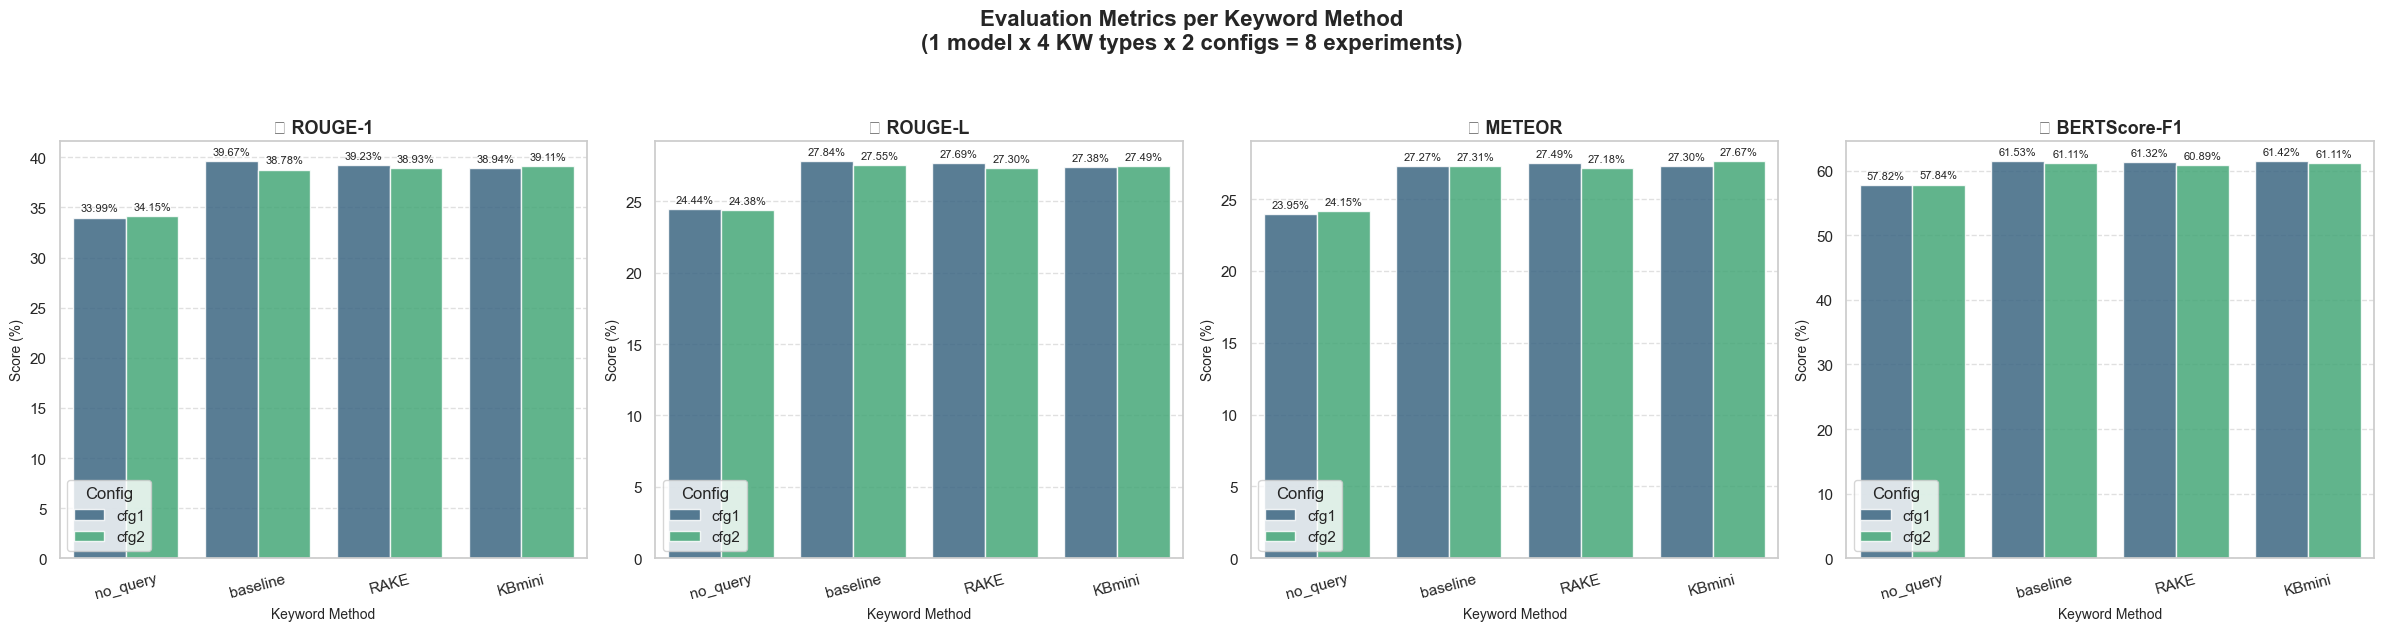

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Evaluation Metrics per Keyword Method\n(1 model x 4 KW types x 2 configs = 8 experiments)',
             fontsize=16, fontweight='bold', y=1.05)

metrics_to_plot = ['ROUGE-1', 'ROUGE-L', 'METEOR', 'BERTScore-F1']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=df_results, x='Keyword', y=metric,
                hue='Config', ax=axes[i], palette='viridis', alpha=0.85)
    axes[i].set_title(f'📊 {metric}', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Keyword Method', fontsize=10)
    axes[i].set_ylabel('Score (%)', fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
    
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f%%', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('eval_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 12.3 Heatmap ROUGE-1 (Config × Keyword)

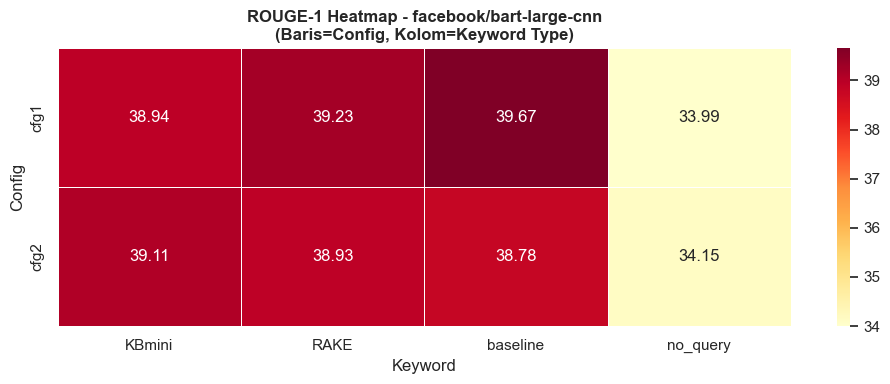

In [ ]:
for model_short in df_results['Model'].unique():
    subset = df_results[df_results['Model'] == model_short]
    pivot  = subset.pivot_table(index='Config', columns='Keyword', values='ROUGE-1')
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
    ax.set_title(f'ROUGE-1 Heatmap - {model_short}\n(Baris=Config, Kolom=Keyword Type)',
                 fontweight='bold')
    plt.tight_layout()
    # Ganti karakter slash agar aman saat disimpan sebagai file image
    model_name_safe = model_short.replace('/', '_')
    plt.savefig(f'eval_heatmap_{model_name_safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


### 12.4 BERTScore vs ROUGE Scatter

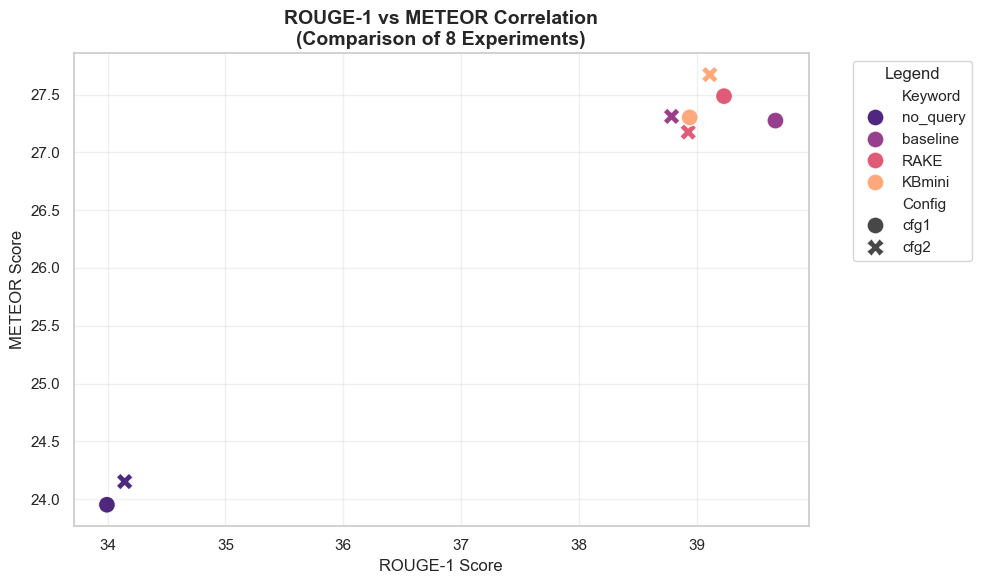

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_results, x='ROUGE-1', y='METEOR', 
                hue='Keyword', style='Config', s=150, alpha=0.9, palette='magma')

plt.title('ROUGE-1 vs METEOR Correlation\n(Comparison of 8 Experiments)', fontweight='bold', fontsize=14)
plt.xlabel('ROUGE-1 Score', fontsize=12)
plt.ylabel('METEOR Score', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Legend')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eval_rouge_vs_meteor.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.5 Word Cloud Generated Summary Terbaik

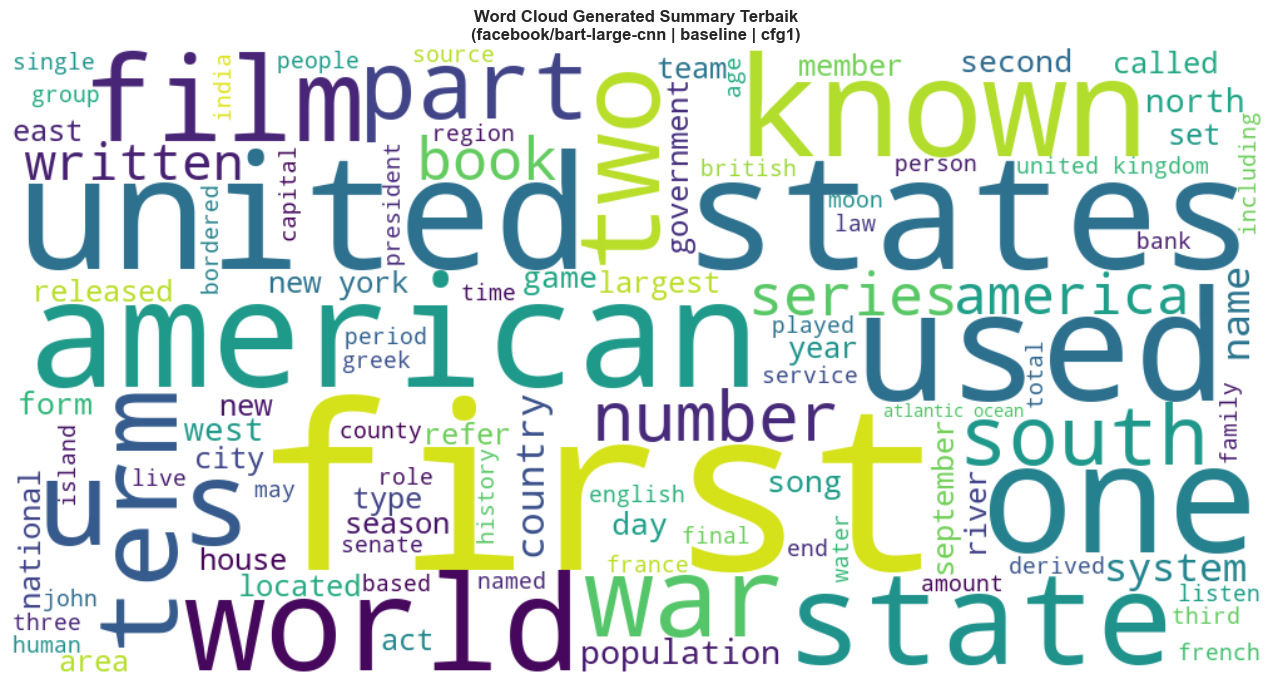

In [ ]:
best_key   = df_results.sort_values('ROUGE-1', ascending=False).iloc[0]
best_label = f"{best_key['Keyword']}_{best_key['Config']}" # format key di all_predictions
if best_label in all_predictions:
    text = ' '.join(all_predictions[best_label])
    wc   = WordCloud(width=1000, height=500, background_color='white',
                     max_words=100, colormap='viridis').generate(text)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud Generated Summary Terbaik\n({best_key["Model"]} | {best_key["Keyword"]} | {best_key["Config"]})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('eval_wordcloud_best_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Key [{best_label}] tidak ditemukan di all_predictions.")


### 12.6 Daftar Semua File Output

| File | Keterangan |
|---|---|
| `eda_distribusi_panjang_raw.png` | Histogram + boxplot panjang teks (raw) |
| `eda_url_distribution.png` | Distribusi URL + scrape success rate |
| `eda_query_analysis.png` | Distribusi panjang query + kata tanya |
| `eda_wordcloud_raw.png` | Word cloud 3 kolom (raw) |
| `eda_top_words_raw.png` | Top-20 kata per kolom (raw) |
| `eda_korelasi_panjang.png` | Scatter korelasi panjang teks |
| `eda_ngram_analysis.png` | Bigram & trigram analysis |
| `eda_preprocessing_comparison.png` | Sebelum vs sesudah preprocessing |
| `eda_wordcloud_clean.png` | Word cloud 3 kolom (clean) |
| `eda_retrieval_comparison.png` | Sebelum vs sesudah retrieval |
| `repr_zipf_bow.png` | Distribusi frekuensi kata (Zipf) |
| `repr_tfidf_idf_analysis.png` | Analisis nilai IDF kata |
| `repr_tfidf_heatmap.png` | Heatmap TF-IDF doc ↔ kata |
| `repr_cosine_similarity.png` | Cosine similarity query ↔ dokumen |
| `repr_lsa_variance.png` | Explained variance LSA |
| `repr_lda_topics.png` | Topik LDA + top kata |
| `repr_lda_topic_distribution.png` | Distribusi topik dominan |
| `repr_word2vec_pca.png` | Embedding Word2Vec (PCA 2D) |
| `repr_bart_token_analysis.png` | Analisis panjang token BART |
| `eda_keyword_length_comparison.png` | Distribusi panjang keyword per metode |
| `eda_keyword_wordcloud_comparison.png` | Word cloud keyword per metode |
| `eval_metrics_comparison.png` | Bar chart metrik evaluasi (ROUGE, METEOR, BERTScore) per kombinasi |
| `eval_heatmap_facebook_bart-large-cnn.png` | Heatmap ROUGE-1 (Config vs Keyword Type) |
| `eval_rouge_vs_meteor.png` | Scatter plot korelasi ROUGE-1 vs METEOR |
| `eval_wordcloud_best_summary.png` | Word cloud dari ringkasan generated terbaik |
| `final_evaluation_results.csv` | Tabel lengkap seluruh metrik hasil evaluasi |
